# Data Center Cooling Demand, Electricity and Water Requirement Analysis

## Problem Statement

Data centers consume significant amounts of electricity, which is ultimately converted into heat and must be removed through cooling systems. Efficiently estimating cooling requirements and the associated water demand is important for reducing energy and water consumption.

This project analyzes data center workload, power consumption, temperature, and cooling-related parameters to understand their relationship with heat generation and estimate the water required for cooling.

## Objective

To develop a predictive analytics system that analyzes data center operational conditions and predicts cooling and water requirements while studying the relationship between workload, electricity consumption, heat generation, and cooling demand.

## Proposed Approach

The project follows an end-to-end predictive analytics approach:

- Exploratory Data Analysis of data center operational data
- Feature engineering and extraction
- Thermal and energy-related measure creation
- Physics-based estimation of cooling and water requirements
- Feature selection
- Predictive modeling
- Model evaluation and comparison
- Cooling and water-demand analysis
- Decision-support insights

#### Step 1: Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#### Step 2: Data Loading

In [ ]:
df = pd.read_csv('Tu-wien.csv')
df.head()

,Series,Time,CPU_Load,Power,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Fan_speed1,Fan_speed2,Fan_speed3,Fan_speed4,Ram,Ram_Used,No_Of_Running_vms,CPU_cores,CPU_cores_used
0,qh2-rcc120,2018-10-09 11:20:00,3.468500,90.533333,408343.338389,147737.953254,16.966667,37.083333,36.716667,7502.833333,7571.666667,7500.500000,7462.000000,64.454875,37.70275,15.0,64.0,63.0
1,qh2-rcc120,2018-10-09 11:30:00,3.622833,88.933333,44589.407008,202395.924763,17.000000,37.783333,37.083333,7141.166667,7182.000000,7147.000000,7113.166667,64.454875,37.70275,15.0,64.0,63.0
2,qh2-rcc120,2018-10-09 11:40:00,3.414500,88.800000,40146.872453,157905.963285,17.000000,38.233333,37.466667,6728.166667,6802.833333,6743.333333,6729.333333,64.454875,37.70275,15.0,64.0,63.0
3,qh2-rcc120,2018-10-09 11:50:00,3.332500,89.866667,441692.385339,142941.034500,17.000000,38.183333,37.550000,6813.333333,6856.500000,6808.666667,6771.333333,64.454875,37.70275,15.0,64.0,63.0
4,qh2-rcc120,2018-10-09 12:00:00,3.364000,89.600000,422057.822324,770341.893781,16.950000,37.416667,36.866667,7390.833333,7445.666667,7401.333333,7351.166667,64.454875,37.70275,15.0,64.0,63.0


#### Step 3: Data Profiling

In [ ]:
def data_profile(data):
    print(15 * '*', "DATA SHAPE", 15 * '*')
    print("Shape:", data.shape)

    print(15 * '*', "DATA COLUMNS & DTYPES", 15 * '*')
    print("Columns:")
    print(data.columns.tolist())
    print("\nData Types:")
    print(data.dtypes)

    print(15 * '*', "DATA INFO", 15 * '*')
    data.info()

    print(15 * '*', "DATA DESCRIPTION", 15 * '*')
    print(data.describe(include="all"))

    print(15 * '*', "MISSING VALUES", 15 * '*')
    print("Missing Count:")
    print(data.isna().sum())

    print("\nMissing Percentage:")
    print(data.isna().mean().mul(100).round(2))

    print(15 * '*', "DUPLICATES IDENTIFICATION", 15 * '*')
    print("Duplicate Rows:", data.duplicated().sum())

    print(15 * '*', "UNIQUE VALUES / CARDINALITY", 15 * '*')
    print(data.nunique(dropna=False))

    print(15 * '*', "CATEGORICAL VALUE COUNTS", 15 * '*')
    categorical_cols = data.select_dtypes(include=["object", "category", "bool"]).columns
    for col in categorical_cols:
        print(f"\n{col}:")
        print(data[col].value_counts(dropna=False))

    print(15 * '*', "DATA CORRELATION", 15 * '*')
    print(data.corr(numeric_only=True))

In [ ]:
data_profile(df)

*************** DATA SHAPE ***************
Shape: (36508, 18)
*************** DATA COLUMNS & DTYPES ***************
Columns:
['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used']

Data Types:
Series                object
Time                  object
CPU_Load             float64
Power                float64
Network_RX           float64
Network_TX           float64
Inlet_Temperature    float64
CPU1_Temperature     float64
CPU2_Temperature     float64
Fan_speed1           float64
Fan_speed2           float64
Fan_speed3           float64
Fan_speed4           float64
Ram                  float64
Ram_Used             float64
No_Of_Running_vms    float64
CPU_cores            float64
CPU_cores_used       float64
dtype: object
*************** DATA INFO ***************
<class 'pandas.core.frame.Da

#### Step 4: Data Cleaning

In [ ]:
# Columns Standardization
df.columns = df.columns.str.strip()

# Datatype Conversions
df["Time"] = pd.to_datetime(df["Time"])
df['Series'] = df['Series'].astype('string')

Missing Values

In [ ]:
df[df.isna().any(axis=1)]
missing_rows = df[df.isna().any(axis=1)]
print("Missing Rows Shape: ", missing_rows.shape)
print("Missing counts:\n ", missing_rows.isna().sum())

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

print("Missingess by Series-Inlet_temp\n", df[df["Inlet_Temperature"].isna()]["Series"].value_counts())
print("Missingess by Series-Fan_Speed1\n", df[df["Fan_speed1"].isna()]["Series"].value_counts())

print("Missingess by Series-Inlet_temp\n", df[df["Inlet_Temperature"].isna()]["Time"].min())
print("Missingess by Series-Fan_Speed1\n", df[df["Inlet_Temperature"].isna()]["Time"].max())

print("Missing more than 5 vales per row\n", df[df.isna().sum(axis=1) >= 5].head())
print("Missing more than 5 vales per row by Seires and Time\n", df[df.isna().sum(axis=1) >= 5][["Series", "Time"]].head(20))

Missing Rows Shape:  (1, 18)
Missing counts:
  Series               0
Time                 0
CPU_Load             0
Power                0
Network_RX           0
Network_TX           0
Inlet_Temperature    0
CPU1_Temperature     0
CPU2_Temperature     0
Fan_speed1           0
Fan_speed2           0
Fan_speed3           1
Fan_speed4           1
Ram                  1
Ram_Used             1
No_Of_Running_vms    1
CPU_cores            1
CPU_cores_used       1
dtype: int64
Missing values per row
 0    18259
7        1
Name: count, dtype: int64
Missingess by Series-Inlet_temp
 Series([], Name: count, dtype: Int64)
Missingess by Series-Fan_Speed1
 Series([], Name: count, dtype: Int64)
Missingess by Series-Inlet_temp
 NaT
Missingess by Series-Fan_Speed1
 NaT
Missing more than 5 vales per row
             Series                Time   CPU_Load  Power     Network_RX  \
18259  qh2-rcc120  2019-02-17 07:00:00  35.014667  352.0  140947.522519   

          Network_TX  Inlet_Temperature  CPU1_Temper

Filling Missing Values

In [ ]:
# Only one missing Values

one_missing = df[df.isna().sum(axis=1) == 1]
print("Shape of 1-missing values: ", one_missing.shape)
display(one_missing.head())

# Interpolation of Missing values
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = (df.groupby("Series")[numeric_cols].transform(lambda x: x.interpolate(method="linear")))

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

Shape of 1-missing values:  (0, 18)


,Series,Time,CPU_Load,Power,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Fan_speed1,Fan_speed2,Fan_speed3,Fan_speed4,Ram,Ram_Used,No_Of_Running_vms,CPU_cores,CPU_cores_used


Missing values per row
 0    18260
Name: count, dtype: int64


In [ ]:
# Five missing Values

five_missing = df[df.isna().sum(axis=1) == 5]
display(five_missing.groupby("Series")["Time"].agg(["min", "max", "count"]).sort_values("count", ascending=False))
display(five_missing.isna().sum())

# Filling of 5-missing values through Interpolation
df = df.sort_values(["Series", "Time"])
cols_to_fill = ["Inlet_Temperature", "Fan_speed1", "Fan_speed2", "Fan_speed3", "Fan_speed4"]

df[cols_to_fill] = (df.groupby("Series")[cols_to_fill].transform(lambda x: x.interpolate(method="linear")))
df = df.dropna() # Some values are not getting interpolated due to non linearity in data so dropping the remaining values of missing 5 and above 5 values per row

,min,max,count
Series,,,


,0
Series,0
Time,0
CPU_Load,0
Power,0
Network_RX,0
Network_TX,0
Inlet_Temperature,0
CPU1_Temperature,0
CPU2_Temperature,0
Fan_speed1,0


In [ ]:
# Checking missing values per row

missing_per_row = df.isna().sum(axis=1)
print("Missing values per row\n", missing_per_row.value_counts().sort_index())

Missing values per row
 0    18260
Name: count, dtype: int64


In [ ]:
# Checking for Invalid Values
numeric_cols = df.select_dtypes(include="number").columns
print("Checking for negative values:\n", (df[numeric_cols] < 0).sum())

print("Checking for CPU cores usage: ", (df["CPU_cores_used"] > df["CPU_cores"]).sum())

print("Checking for Ram usage: ", (df["Ram_Used"] > df["Ram"]).sum())

print("Checking for valid vms: ", (df["No_Of_Running_vms"] < 0).sum())

print("Checking for valid CPU load: ", (df["CPU_Load"] < 0).sum())

print("Number of inf values in cols:\n", np.isinf(df[numeric_cols]).sum())

Checking for negative values:
 CPU_Load             0
Power                0
Network_RX           0
Network_TX           0
Inlet_Temperature    0
CPU1_Temperature     0
CPU2_Temperature     0
Fan_speed1           0
Fan_speed2           0
Fan_speed3           0
Fan_speed4           0
Ram                  0
Ram_Used             0
No_Of_Running_vms    0
CPU_cores            0
CPU_cores_used       0
dtype: int64
Checking for CPU cores usage:  20
Checking for Ram usage:  0
Checking for valid vms:  0
Checking for valid CPU load:  0
Number of inf values in cols:
 CPU_Load             0
Power                0
Network_RX           0
Network_TX           0
Inlet_Temperature    0
CPU1_Temperature     0
CPU2_Temperature     0
Fan_speed1           0
Fan_speed2           0
Fan_speed3           0
Fan_speed4           0
Ram                  0
Ram_Used             0
No_Of_Running_vms    0
CPU_cores            0
CPU_cores_used       0
dtype: int64


In [ ]:
# Invalid CPU cores Investigation

invalid_cpu = df[df["CPU_cores_used"] > df["CPU_cores"]]
display(invalid_cpu[["Series", "Time", "CPU_cores", "CPU_cores_used"]].head(20))
display(invalid_cpu[["CPU_cores", "CPU_cores_used"]].value_counts())
display(invalid_cpu["Series"].value_counts())

,Series,Time,CPU_cores,CPU_cores_used
2163,qh2-rcc120,2018-10-24 11:50:00,64.0,78.333333
2164,qh2-rcc120,2018-10-24 12:00:00,64.0,80.000000
2165,qh2-rcc120,2018-10-24 12:10:00,64.0,80.000000
2166,qh2-rcc120,2018-10-24 12:20:00,64.0,80.000000
2167,qh2-rcc120,2018-10-24 12:30:00,64.0,80.000000
2168,qh2-rcc120,2018-10-24 12:40:00,64.0,80.000000
2169,qh2-rcc120,2018-10-24 12:50:00,64.0,80.000000
2170,qh2-rcc120,2018-10-24 13:00:00,64.0,80.000000
2171,qh2-rcc120,2018-10-24 13:10:00,64.0,80.000000
2172,qh2-rcc120,2018-10-24 13:20:00,64.0,80.000000


CPU_cores  CPU_cores_used
64.0       80.000000         19
           78.333333          1
Name: count, dtype: int64

,count
Series,
qh2-rcc120,20


**The CPU_cores_used values exceeding CPU_cores were investigated and retained, as the metric may not directly represent the number of physical CPU cores in use.**

Final Profiling

In [ ]:
data_profile(df)

*************** DATA SHAPE ***************
Shape: (18260, 18)
*************** DATA COLUMNS & DTYPES ***************
Columns:
['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used']

Data Types:
Series               string[python]
Time                 datetime64[ns]
CPU_Load                    float64
Power                       float64
Network_RX                  float64
Network_TX                  float64
Inlet_Temperature           float64
CPU1_Temperature            float64
CPU2_Temperature            float64
Fan_speed1                  float64
Fan_speed2                  float64
Fan_speed3                  float64
Fan_speed4                  float64
Ram                         float64
Ram_Used                    float64
No_Of_Running_vms           float64
CPU_cores                   fl

Save the cleaned Dataset

In [ ]:
df.to_csv("Cleaned_Tu-wien.csv", index=False)

In [ ]:
# Loading the cleaned Dataset

df = pd.read_csv("Cleaned_Tu-wien.csv")

#### Step 5: Analysis and Visualization

**Time Variate Analysis**

**1. Power Over Time**

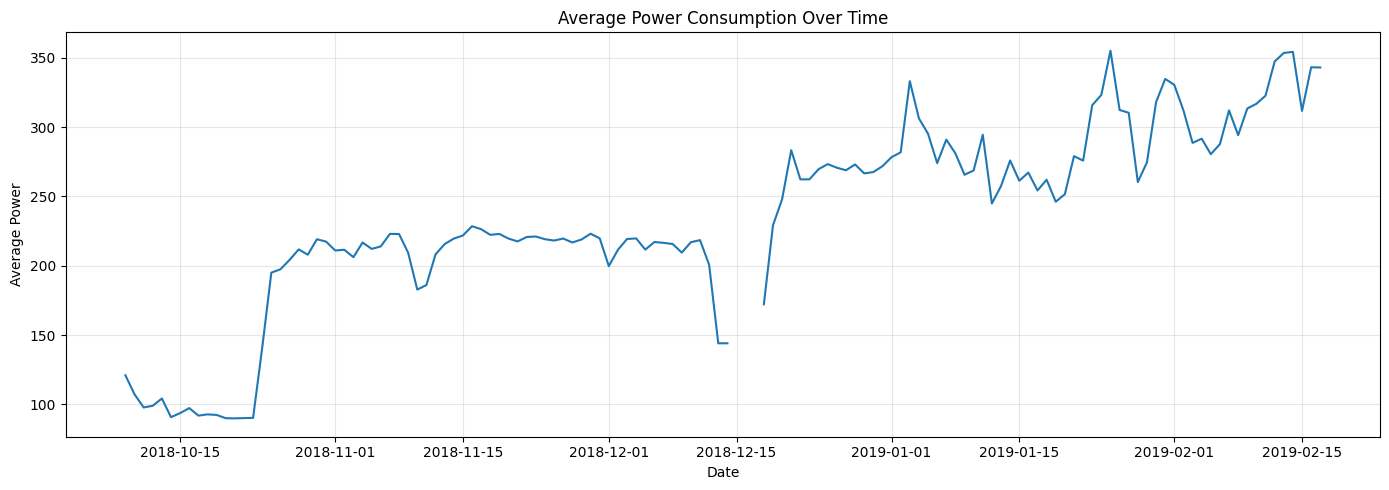

In [ ]:
df['Time'] = pd.to_datetime(df['Time'])
daily_power = (df.set_index("Time")["Power"].resample("D").mean())

plt.figure(figsize=(14, 5))
plt.plot(daily_power.index, daily_power.values)
plt.title("Average Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Average Power")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Average Power by day of week**

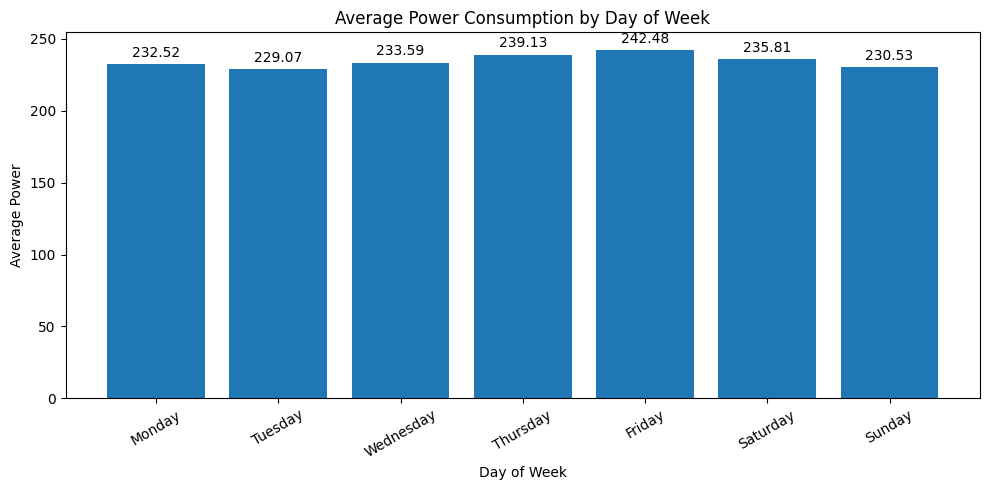

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day_of_Week"] = df["Time"].dt.day_name()
weekday_power = (df.groupby("Day_of_Week")["Power"].mean().reindex(day_order))

plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_power.index, weekday_power.values)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Average Power Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Power")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Univariate analysis**

**3. Numerical Feature Distributions**

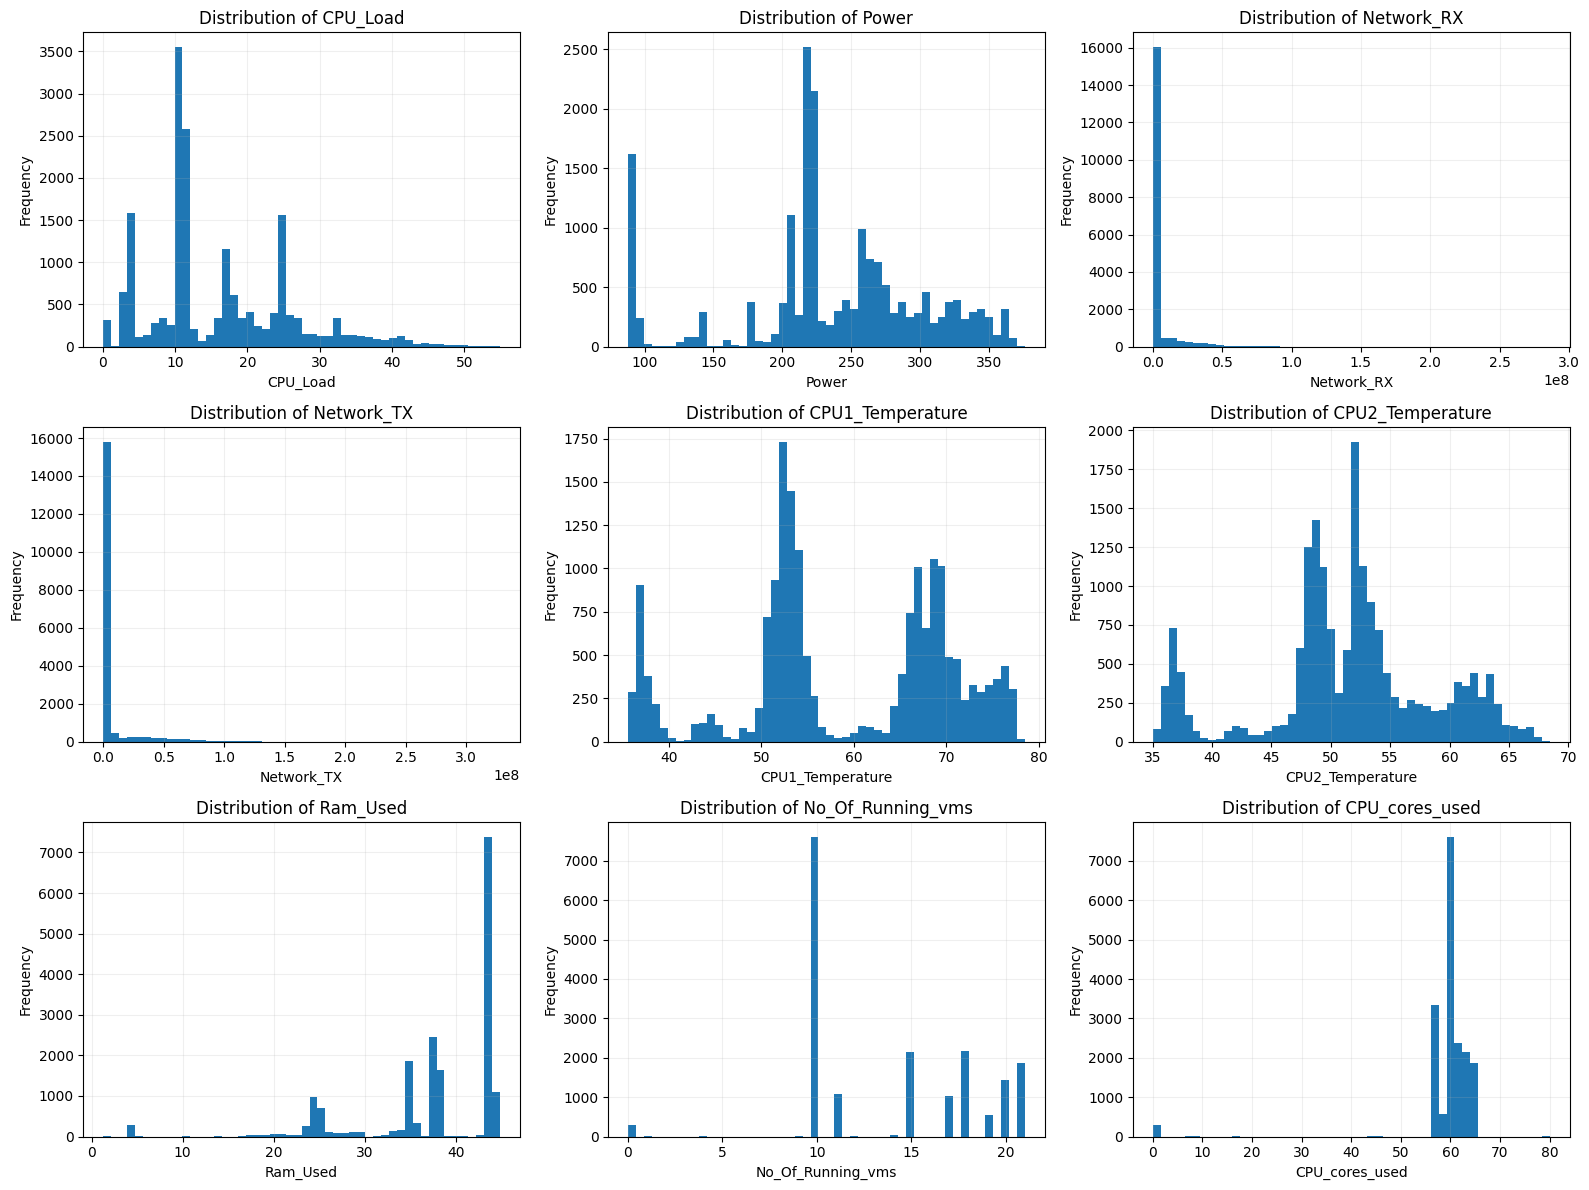

In [ ]:
dist_cols = [
    "CPU_Load",
    "Power",
    "Network_RX",
    "Network_TX",
    "CPU1_Temperature",
    "CPU2_Temperature",
    "Ram_Used",
    "No_Of_Running_vms",
    "CPU_cores_used"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, dist_cols):
    ax.hist(df[col], bins=50)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**4. Outlier Inspection**

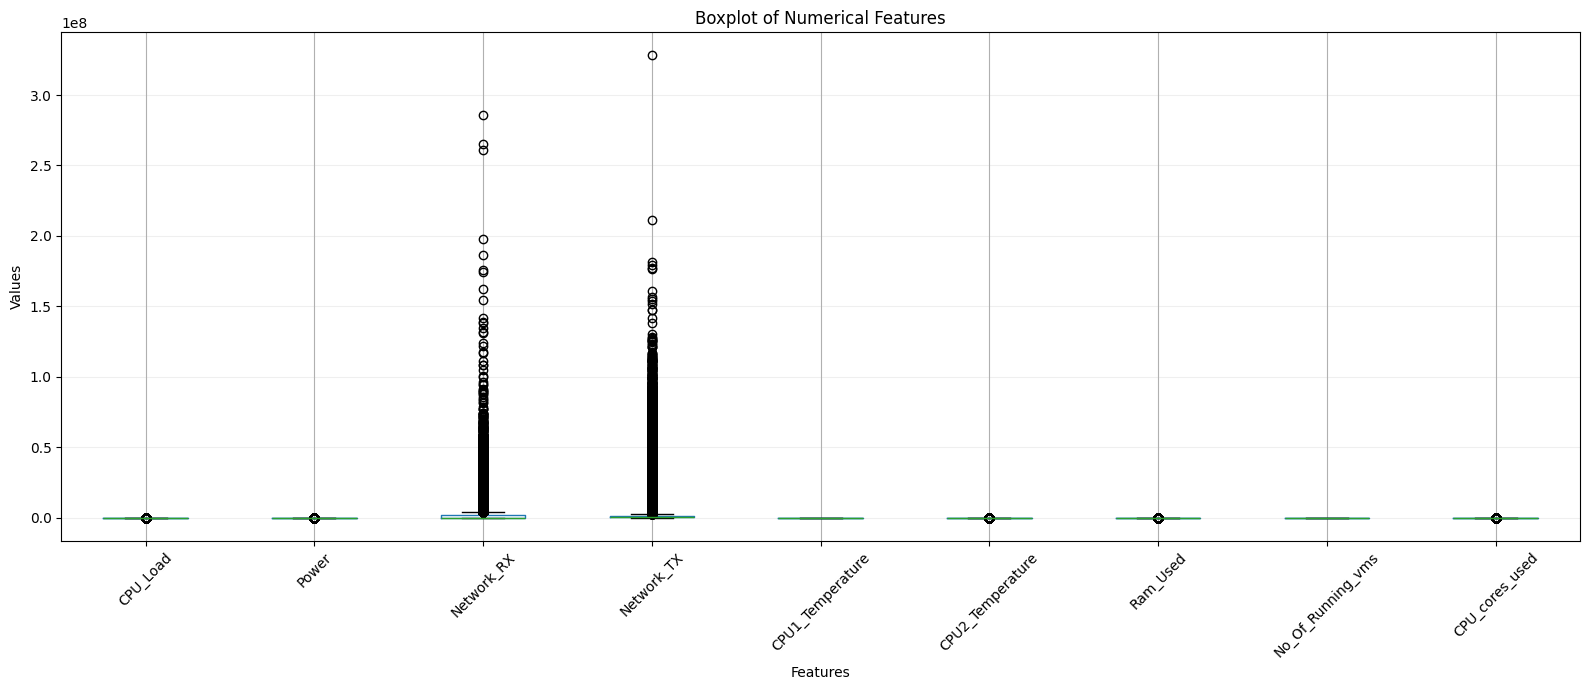

In [ ]:
box_cols = [
    "CPU_Load",
    "Power",
    "Network_RX",
    "Network_TX",
    "CPU1_Temperature",
    "CPU2_Temperature",
    "Ram_Used",
    "No_Of_Running_vms",
    "CPU_cores_used"
]

plt.figure(figsize=(16, 7))
df[box_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Series analysis**

**5. Average Power by Server**

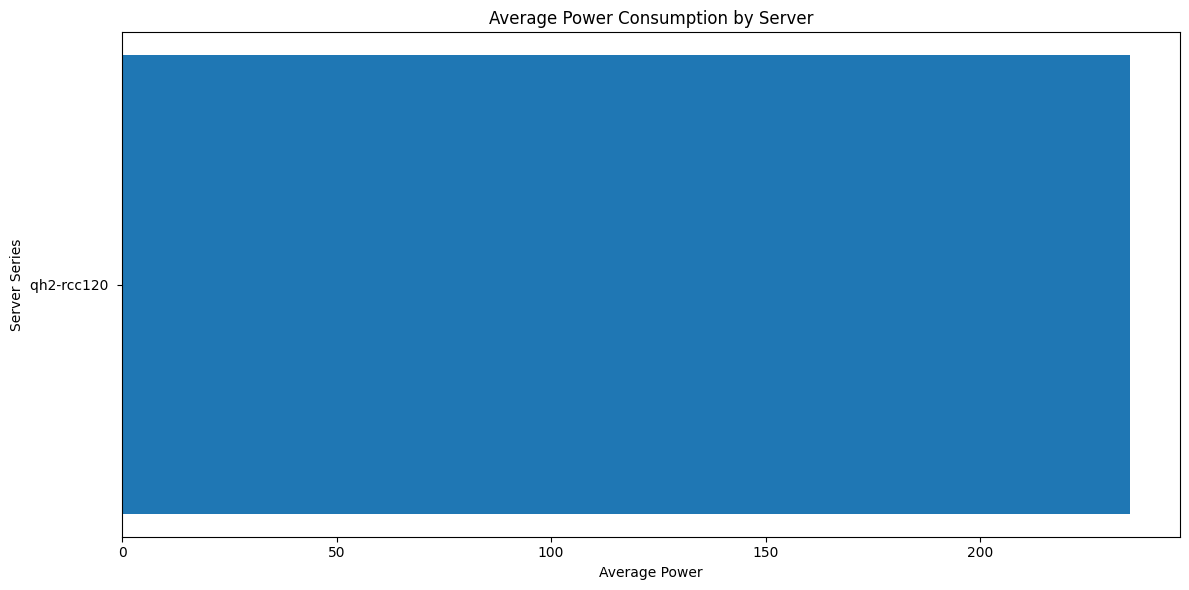

In [ ]:
series_power = (df.groupby("Series")["Power"].mean().sort_values()).head(10)

plt.figure(figsize=(12, 6))
plt.barh(series_power.index, series_power.values)
plt.title("Average Power Consumption by Server")
plt.xlabel("Average Power")
plt.ylabel("Server Series")
plt.tight_layout()
plt.show()

**Relationship Analysis**

**6. Correlation Heatmap**

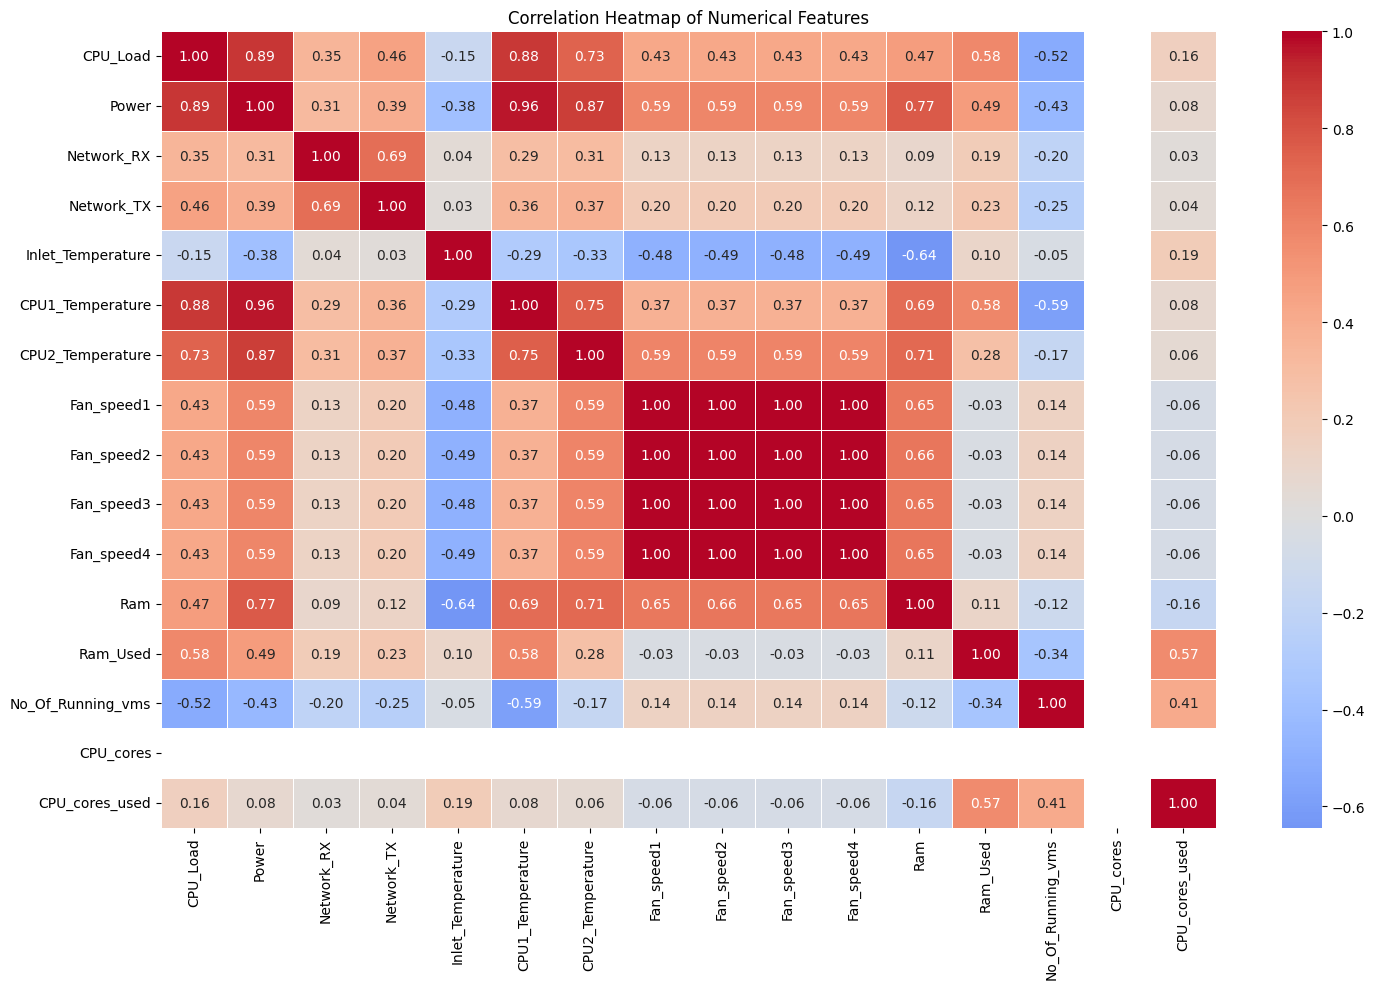

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**7. Grouped System Relationships**

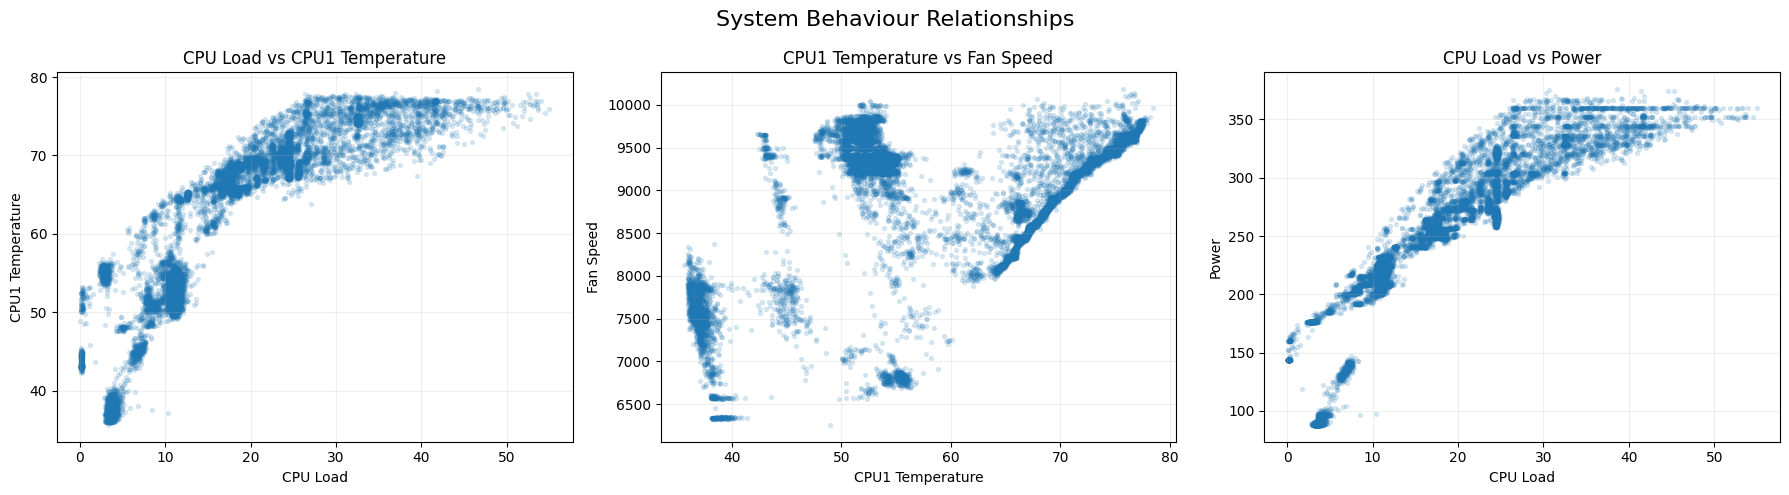

In [ ]:
sample = df.sample(n=min(50000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. CPU Load vs CPU Temperature
axes[0].scatter(
    sample["CPU_Load"],
    sample["CPU1_Temperature"],
    alpha=0.15,
    s=8
)
axes[0].set_title("CPU Load vs CPU1 Temperature")
axes[0].set_xlabel("CPU Load")
axes[0].set_ylabel("CPU1 Temperature")
axes[0].grid(True, alpha=0.2)

# 2. CPU Temperature vs Fan Speed
axes[1].scatter(
    sample["CPU1_Temperature"],
    sample["Fan_speed1"],
    alpha=0.15,
    s=8
)
axes[1].set_title("CPU1 Temperature vs Fan Speed")
axes[1].set_xlabel("CPU1 Temperature")
axes[1].set_ylabel("Fan Speed")
axes[1].grid(True, alpha=0.2)

# 3. CPU Load vs Power
axes[2].scatter(
    sample["CPU_Load"],
    sample["Power"],
    alpha=0.15,
    s=8
)
axes[2].set_title("CPU Load vs Power")
axes[2].set_xlabel("CPU Load")
axes[2].set_ylabel("Power")
axes[2].grid(True, alpha=0.2)
plt.suptitle("System Behaviour Relationships", fontsize=16)
plt.tight_layout()
plt.show()

**Findings from above EDAV Plots**

- Power consumption shows variation over the observed time period, indicating that server power usage is not completely constant.

- The average power consumption varies across different days of the week, suggesting some differences in server activity depending on the day.

- The numerical features show different distributions and scales. In particular, Network_RX and Network_TX are highly right-skewed compared with most of the other variables.

- The boxplots indicate the presence of extreme values in several numerical variables. These values should be investigated further rather than removed automatically.

- The correlation heatmap shows strong relationships between several system metrics. CPU_Load and Power have a strong positive correlation, while CPU1_Temperature and CPU2_Temperature are also strongly correlated.

- The four fan-speed variables show extremely high correlation with each other, indicating that they provide very similar information.

- CPU Load and CPU Temperature show a positive relationship, suggesting that higher computational activity is generally associated with higher CPU temperature.

- CPU Temperature and Fan Speed also show a relationship, indicating changes in cooling activity as CPU temperature changes.

- Overall, the EDA shows that the dataset contains several related system-performance variables, along with some highly correlated and potentially redundant features.

#### Step 6: Feature Engineering and Extraction

**Workload Features**

The following features are derived from CPU, memory, network, and virtual-machine measurements to represent the computational workload of the data-center host.

**CPU Core Utilization**
$$
\text{CPU Core Utilization} = \frac{\text{Used CPU Cores}}{\text{Total CPU Cores}} \times 100
$$
This represents the percentage of available CPU cores currently being used.

**RAM Utilization**
$$
\text{RAM Utilization} = \frac{\text{Used RAM}}{\text{Total RAM}} \times 100
$$
This represents the percentage of available RAM currently being utilized.

**Total Network Traffic**
$$
\text{Total Network Traffic} = \text{Network RX} + \text{Network TX}
$$
This combines incoming and outgoing network traffic into a single measure of overall network activity.

**VM Density**
$$
\text{VM Density} = \frac{\text{Running VMs}}{\text{Total CPU Cores}}
$$
This represents the number of running virtual machines relative to the available CPU cores.|

In [ ]:
df['CPU_Core_Utilization'] = (df['CPU_cores_used'] / df['CPU_cores']) * 100

df['RAM_Utilization'] = (df['Ram_Used'] / df['Ram']) * 100

df['Total_Network'] = (df['Network_RX'] + df['Network_TX'])

df['VM_Density'] = (df['No_Of_Running_vms'] / df['CPU_cores'])

# Display the newly created features
display(df[['CPU_Core_Utilization', 'RAM_Utilization', 'Total_Network', 'VM_Density']].head())

# Checking descriptive statistics of newly created workload features
display(df[['CPU_Core_Utilization', 'RAM_Utilization', 'Total_Network', 'VM_Density']].describe())


,CPU_Core_Utilization,RAM_Utilization,Total_Network,VM_Density
0,98.4375,58.4948,5.560813e+05,0.234375
1,98.4375,58.4948,2.469853e+05,0.234375
2,98.4375,58.4948,1.980528e+05,0.234375
3,98.4375,58.4948,5.846334e+05,0.234375
4,98.4375,58.4948,1.192400e+06,0.234375


,CPU_Core_Utilization,RAM_Utilization,Total_Network,VM_Density
count,18260.000000,18260.000000,1.826000e+04,18260.000000
mean,92.652556,58.373906,9.822880e+06,0.219057
std,12.591460,12.472692,2.635779e+07,0.072645
min,0.000000,1.936505,0.000000e+00,0.000000
25%,93.750000,54.495973,2.932928e+05,0.156250
50%,93.750000,58.862753,7.435307e+05,0.234375
75%,96.875000,67.992107,2.723355e+06,0.281250
max,125.000000,69.579999,4.669701e+08,0.328125


**Thermal Features**

**Temperature Rise**
$$
\text{Temperature Rise} = \text{Average CPU Temperature} - \text{Inlet Temperature}
$$
This measures how much the average CPU temperature rises above the incoming air temperature.

In [ ]:
df['Avg_CPU_Temperature'] = (df['CPU1_Temperature'] + df['CPU2_Temperature']) / 2

df['Max_CPU_Temperature'] = df[['CPU1_Temperature', 'CPU2_Temperature']].max(axis=1)

df['CPU_Temperature_Diff'] = abs(df['CPU1_Temperature'] - df['CPU2_Temperature'])

df['Temperature_Rise'] = df['Avg_CPU_Temperature'] - df['Inlet_Temperature']

# Checking descriptive statistics of newly created Thermal features
display(df[['Avg_CPU_Temperature', 'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise']].describe())

,Avg_CPU_Temperature,Max_CPU_Temperature,CPU_Temperature_Diff,Temperature_Rise
count,18260.000000,18260.000000,18260.000000,18260.000000
mean,55.218852,58.944555,7.451405,38.762039
std,8.713378,11.424307,7.613975,8.964927
min,35.500000,35.616667,0.000000,17.233333
25%,51.833333,52.083333,0.550000,35.547917
50%,54.483333,55.343333,2.566667,38.613333
75%,60.816667,68.916667,14.650000,44.302083
max,71.491667,78.466667,23.483333,55.175000


In [ ]:
df[['Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Avg_CPU_Temperature', 'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise']].head()

,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Avg_CPU_Temperature,Max_CPU_Temperature,CPU_Temperature_Diff,Temperature_Rise
0,16.966667,37.083333,36.716667,36.900000,37.083333,0.366667,19.933333
1,17.000000,37.783333,37.083333,37.433333,37.783333,0.700000,20.433333
2,17.000000,38.233333,37.466667,37.850000,38.233333,0.766667,20.850000
3,17.000000,38.183333,37.550000,37.866667,38.183333,0.633333,20.866667
4,16.950000,37.416667,36.866667,37.141667,37.416667,0.550000,20.191667


**Cooling Features**

In [ ]:
df['Avg_Fan_Speed'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].mean(axis=1)

df['Max_Fan_Speed'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].max(axis=1)

df['Fan_Speed_Diff'] = df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].max(axis=1) - df[['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4']].min(axis=1)

In [ ]:
# Checking descriptive statistics of newly created Cooling features

df[['Avg_Fan_Speed', 'Max_Fan_Speed', 'Fan_Speed_Diff']].describe()

,Avg_Fan_Speed,Max_Fan_Speed,Fan_Speed_Diff
count,18260.000000,18260.000000,18260.000000
mean,8889.786333,8947.146932,120.267371
std,791.078485,798.177910,32.433009
min,6251.583333,6307.000000,19.833333
25%,8524.979167,8589.000000,99.166667
50%,9166.354167,9231.483333,119.000000
75%,9457.364583,9545.666667,138.833333
max,10174.500000,10266.666667,296.333333


In [ ]:
# Hence all values for 4 fans_speeds are same we are only considering avg_fan_speed

df.drop(columns=['Fan_speed1', 'Fan_speed2', 'Fan_speed3', 'Fan_speed4', 'Max_Fan_Speed', 'Fan_Speed_Diff'], inplace=True)

**Energy Features**

The energy feature normalizes power consumption against the available CPU capacity to represent energy intensity.

**Power per CPU Core**
$$
\text{Power per CPU Core} = \frac{\text{Power Consumption}}{\text{Total CPU Cores}}
$$
This represents the power consumption relative to the available CPU capacity.

In [ ]:
df['Power_per_Core'] = df['Power'] / df['CPU_cores']

df[['Power_per_Core']].describe()

,Power_per_Core
count,18260.000000
mean,3.669069
std,1.076196
min,1.375000
25%,3.275000
50%,3.500000
75%,4.308333
max,5.875000


**Cooling and Water-Demand Modeling**

- The IT power consumption is used to estimate the heat generated by the server infrastructure. Based on this heat load, the required cooling-water flow is estimated for different allowable water temperature rises.

- An additional evaporative-water requirement is estimated using the latent heat of vaporization of water. These values represent physics-based estimates rather than directly measured water consumption.

**Heat Load Estimation**

The electrical power consumed by the IT equipment is assumed to be approximately equivalent to the heat generated by the equipment.

$$
\text{Heat Load (kW)} = \frac{\text{Power Consumption (W)}}{1000}
$$

This converts the measured power consumption from watts to kilowatts and represents the estimated heat generated by the IT equipment.

In [ ]:
# Heat load from IT power consumption
df['Heat_Load_kW'] = df['Power'] / 1000

**Cooling Water Requirement**

The cooling-water requirement is estimated using the heat load, specific heat capacity of water, and the desired temperature rise of the cooling water.

$$
\text{Water Flow (L/hour)} = \frac{\text{Heat Load (kW)}}{C_p \times \Delta T} \times 3600
$$

where:
- $C_p = 4.186$ kJ/(kg·°C) — specific heat capacity of water
- $\Delta T$ — allowable temperature rise of cooling water
- $3600$ — converts seconds to hours

Three cooling scenarios are considered:

$$
\text{Water Flow}_{3°C} = \frac{\text{Heat Load}}{C_p \times 3} \times 3600
$$

$$
\text{Water Flow}_{5°C} = \frac{\text{Heat Load}}{C_p \times 5} \times 3600
$$

$$
\text{Water Flow}_{10°C} = \frac{\text{Heat Load}}{C_p \times 10} \times 3600
$$

In [ ]:
# Water properties and cooling-system assumptions
CP_WATER = 4.1816  # kJ/(kg·°C) at approximately 25°C

DELTA_T_3C = 3
DELTA_T_5C = 5
DELTA_T_10C = 10

# Cooling-water flow requirement in L/hour
df['Water_Flow_3C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_3C)) * 3600
df['Water_Flow_5C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_5C)) * 3600
df['Water_Flow_10C_LPH'] = (df['Heat_Load_kW'] / (CP_WATER * DELTA_T_10C)) * 3600

**Evaporative Water Requirement**

The evaporative water requirement is estimated using the latent heat of vaporization of water.

$$
\text{Evaporative Water Required (L/hour)} = \frac{\text{Heat Load (kW)}}{H_{fg}} \times 3600
$$

where:

$$
H_{fg} = 2441.7\ \text{kJ/kg}
$$

is the latent heat of vaporization of water at approximately 25°C.

In [ ]:
# Latent heat of vaporization of water at approximately 25°C
H_FG_WATER = 2441.7  # kJ/kg

# Evaporative water requirement in L/hour
df['Evaporative_Water_Required_LPH'] = (
    df['Heat_Load_kW'] / H_FG_WATER
) * 3600

In [ ]:
# Check the resulting measures

df[['Power','Heat_Load_kW', 'Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH', 'Evaporative_Water_Required_LPH']].describe()

,Power,Heat_Load_kW,Water_Flow_3C_LPH,Water_Flow_5C_LPH,Water_Flow_10C_LPH,Evaporative_Water_Required_LPH
count,18260.000000,18260.000000,18260.000000,18260.000000,18260.000000,18260.000000
mean,234.820418,0.234820,67.386766,40.432060,20.216030,0.346215
std,68.876544,0.068877,19.765605,11.859363,5.929681,0.101550
min,88.000000,0.088000,25.253491,15.152095,7.576047,0.129746
25%,209.600000,0.209600,60.149225,36.089535,18.044768,0.309031
50%,224.000000,0.224000,64.281615,38.568969,19.284484,0.330262
75%,275.733333,0.275733,79.127607,47.476564,23.738282,0.406536
max,376.000000,0.376000,107.901282,64.740769,32.370385,0.554368


In [ ]:
df[['Power', 'Heat_Load_kW', 'Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH', 'Evaporative_Water_Required_LPH']].head()

,Power,Heat_Load_kW,Water_Flow_3C_LPH,Water_Flow_5C_LPH,Water_Flow_10C_LPH,Evaporative_Water_Required_LPH
0,90.533333,0.090533,25.980486,15.588292,7.794146,0.133481
1,88.933333,0.088933,25.521332,15.312799,7.656399,0.131122
2,88.800000,0.088800,25.483069,15.289841,7.644921,0.130925
3,89.866667,0.089867,25.789172,15.473503,7.736751,0.132498
4,89.600000,0.089600,25.712646,15.427588,7.713794,0.132105


**Check All columns after Feature Engineering**

In [ ]:
df.columns.to_list()

['Series',
 'Time',
 'CPU_Load',
 'Power',
 'Network_RX',
 'Network_TX',
 'Inlet_Temperature',
 'CPU1_Temperature',
 'CPU2_Temperature',
 'Ram',
 'Ram_Used',
 'No_Of_Running_vms',
 'CPU_cores',
 'CPU_cores_used',
 'Day_of_Week',
 'CPU_Core_Utilization',
 'RAM_Utilization',
 'Total_Network',
 'VM_Density',
 'Avg_CPU_Temperature',
 'Max_CPU_Temperature',
 'CPU_Temperature_Diff',
 'Temperature_Rise',
 'Avg_Fan_Speed',
 'Power_per_Core',
 'Heat_Load_kW',
 'Water_Flow_3C_LPH',
 'Water_Flow_5C_LPH',
 'Water_Flow_10C_LPH',
 'Evaporative_Water_Required_LPH']

#### **Save the Engineered Dataset for ML ready**

In [ ]:
df.to_csv("Tu-wien_ML-Ready.csv", index = False)

#### Step 7: Cooling and Water-Demand Modeling

**Heat Load Analysis**

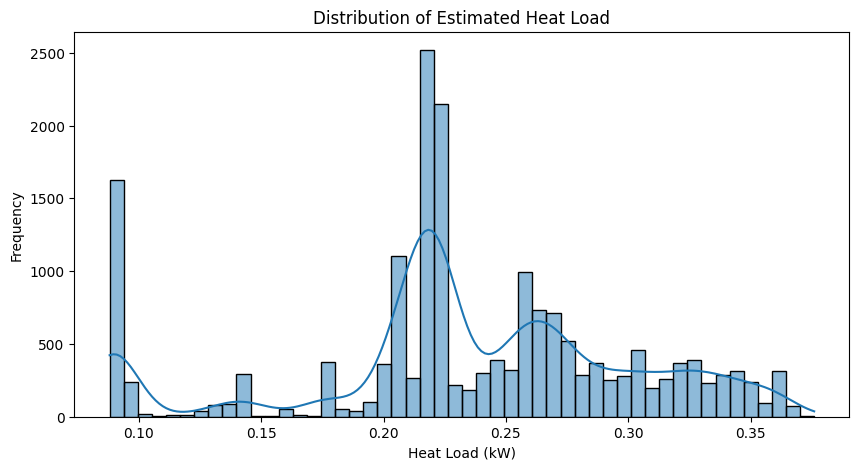

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Heat_Load_kW'], bins=50, kde=True)
plt.title('Distribution of Estimated Heat Load')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Frequency')
plt.show()

**Cooling Water Requirement**

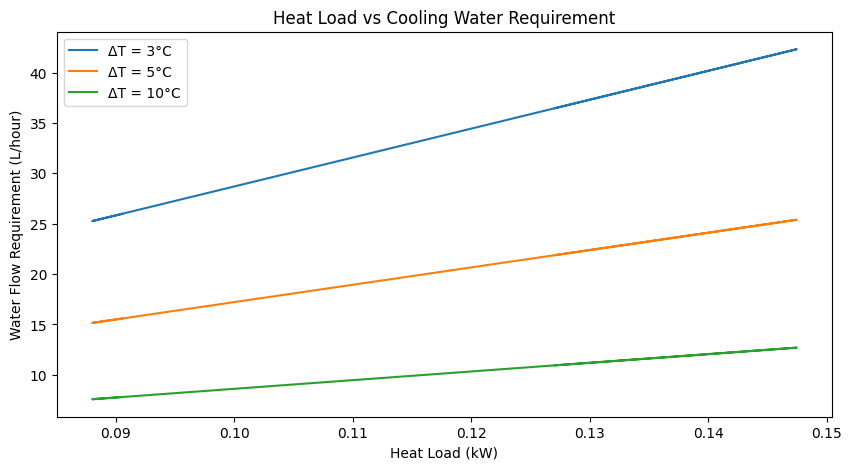

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_3C_LPH'].head(500), label='ΔT = 3°C')
plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_5C_LPH'].head(500), label='ΔT = 5°C')
plt.plot(df['Heat_Load_kW'].head(500), df['Water_Flow_10C_LPH'].head(500), label='ΔT = 10°C')

plt.title('Heat Load vs Cooling Water Requirement')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Water Flow Requirement (L/hour)')
plt.legend()
plt.show()

**Evaporative Water Requirement**

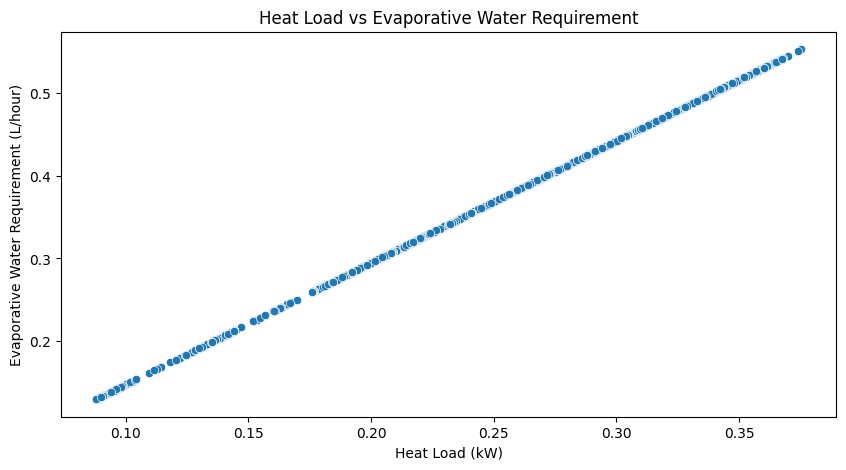

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='Heat_Load_kW',
    y='Evaporative_Water_Required_LPH'
)
plt.title('Heat Load vs Evaporative Water Requirement')
plt.xlabel('Heat Load (kW)')
plt.ylabel('Evaporative Water Requirement (L/hour)')
plt.show()

**Scenario Comparison**

Water_Flow_3C_LPH     67.386766
Water_Flow_5C_LPH     40.432060
Water_Flow_10C_LPH    20.216030
dtype: float64


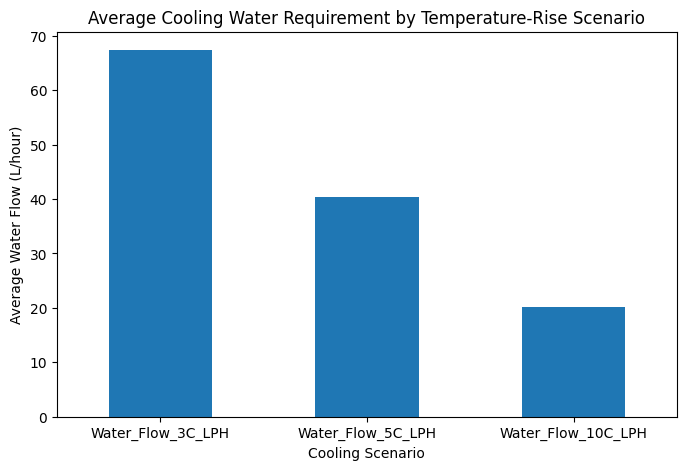

In [ ]:
scenario_means = df[['Water_Flow_3C_LPH', 'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH']].mean()
print(scenario_means)

plt.figure(figsize=(8, 5))
scenario_means.plot(kind='bar')
plt.title('Average Cooling Water Requirement by Temperature-Rise Scenario')
plt.xlabel('Cooling Scenario')
plt.ylabel('Average Water Flow (L/hour)')
plt.xticks(rotation=0)
plt.show()

**Power–Heat–Water Relationships**

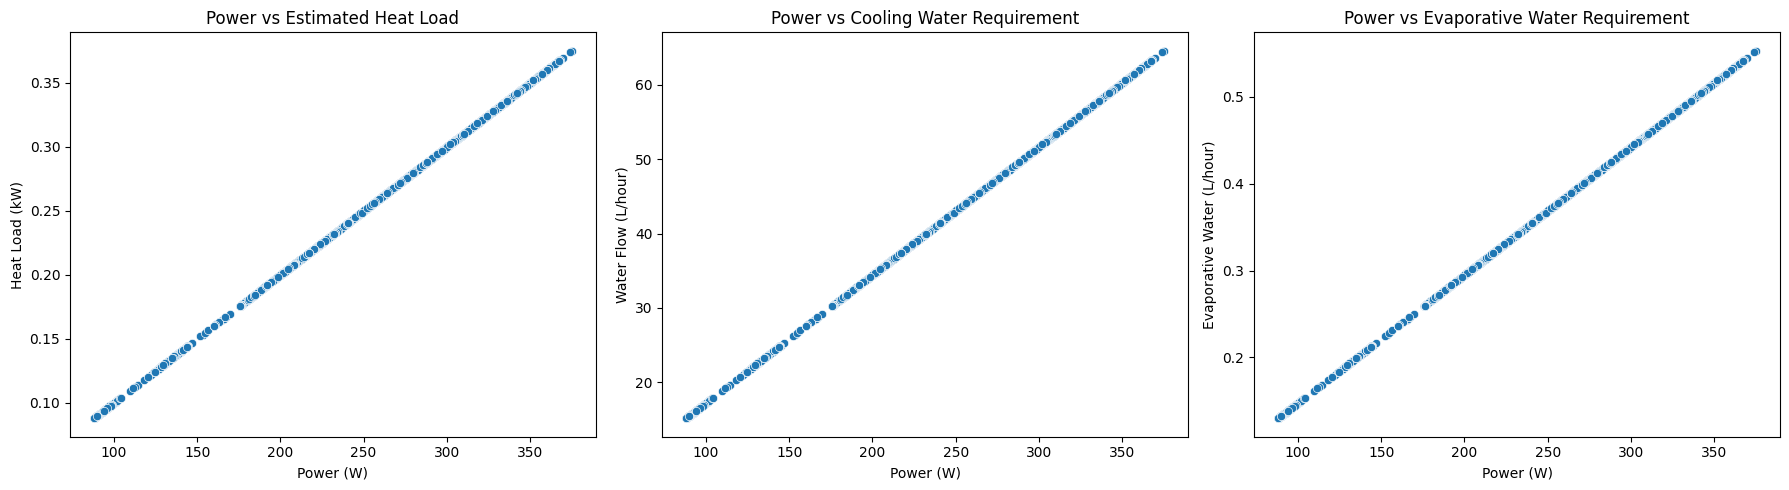

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_df = df.sample(min(10000, len(df)), random_state=42)

# Power vs Heat Load
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Heat_Load_kW',
    ax=axes[0]
)
axes[0].set_title('Power vs Estimated Heat Load')
axes[0].set_xlabel('Power (W)')
axes[0].set_ylabel('Heat Load (kW)')

# Power vs Cooling Water Requirement
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Water_Flow_5C_LPH',
    ax=axes[1]
)
axes[1].set_title('Power vs Cooling Water Requirement')
axes[1].set_xlabel('Power (W)')
axes[1].set_ylabel('Water Flow (L/hour)')

# Power vs Evaporative Water Requirement
sns.scatterplot(
    data=sample_df,
    x='Power',
    y='Evaporative_Water_Required_LPH',
    ax=axes[2]
)
axes[2].set_title('Power vs Evaporative Water Requirement')
axes[2].set_xlabel('Power (W)')
axes[2].set_ylabel('Evaporative Water (L/hour)')

plt.tight_layout()
plt.show()

The analysis shows a strong linear relationship between power consumption, estimated heat load, cooling-water flow requirement, and evaporative water requirement. This is expected because the cooling and water-demand measures are derived from the estimated heat load using thermodynamic relationships. These derived measures establish the physical basis for the subsequent predictive modeling stage.

#### Step 8: Predictive Modelling

### 8.1: Feature Selection

The predictive modelling stage focuses on forecasting evaporative water requirement using data-center operational, workload, thermal, and cooling telemetry.

Two modelling approaches are considered:

1. Overall Predictive Model — learns general relationships across the complete dataset.
2. Per-Series Forecasting Model — models temporal behavior separately for individual data-center servers.

In [30]:
# Load data

data = pd.read_csv("../datasets/Tu-wien_ML-Ready.csv")

data['Time'] = pd.to_datetime(data['Time'])
print("Shape: ", data.shape)
display(data.head())
data.columns

Shape:  (2664813, 30)


,Series,Time,CPU_Load,Power,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Ram,...,Max_CPU_Temperature,CPU_Temperature_Diff,Temperature_Rise,Avg_Fan_Speed,Power_per_Core,Heat_Load_kW,Water_Flow_3C_LPH,Water_Flow_5C_LPH,Water_Flow_10C_LPH,Evaporative_Water_Required_LPH
0,qh2-rcc120,2018-10-09 11:20:00,3.468500,90.533333,408343.338389,147737.953254,16.966667,37.083333,36.716667,64.454875,...,37.083333,0.366667,19.933333,7509.250000,1.414583,0.090533,25.980486,15.588292,7.794146,0.133481
1,qh2-rcc120,2018-10-09 11:30:00,3.622833,88.933333,44589.407008,202395.924763,17.000000,37.783333,37.083333,64.454875,...,37.783333,0.700000,20.433333,7145.833333,1.389583,0.088933,25.521332,15.312799,7.656399,0.131122
2,qh2-rcc120,2018-10-09 11:40:00,3.414500,88.800000,40146.872453,157905.963285,17.000000,38.233333,37.466667,64.454875,...,38.233333,0.766667,20.850000,6750.916667,1.387500,0.088800,25.483069,15.289841,7.644921,0.130925
3,qh2-rcc120,2018-10-09 11:50:00,3.332500,89.866667,441692.385339,142941.034500,17.000000,38.183333,37.550000,64.454875,...,38.183333,0.633333,20.866667,6812.458333,1.404167,0.089867,25.789172,15.473503,7.736751,0.132498
4,qh2-rcc120,2018-10-09 12:00:00,3.364000,89.600000,422057.822324,770341.893781,16.950000,37.416667,36.866667,64.454875,...,37.416667,0.550000,20.191667,7397.250000,1.400000,0.089600,25.712646,15.427588,7.713794,0.132105


Index(['Series', 'Time', 'CPU_Load', 'Power', 'Network_RX', 'Network_TX',
       'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Ram',
       'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used',
       'Day_of_Week', 'CPU_Core_Utilization', 'RAM_Utilization',
       'Total_Network', 'VM_Density', 'Avg_CPU_Temperature',
       'Max_CPU_Temperature', 'CPU_Temperature_Diff', 'Temperature_Rise',
       'Avg_Fan_Speed', 'Power_per_Core', 'Heat_Load_kW', 'Water_Flow_3C_LPH',
       'Water_Flow_5C_LPH', 'Water_Flow_10C_LPH',
       'Evaporative_Water_Required_LPH'],
      dtype='object')

In [32]:
print("Number of Series:", data['Series'].nunique())
print("Time Range:", data['Time'].min(), "→", data['Time'].max())

Number of Series: 76
Time Range: 2018-10-09 11:20:00 → 2019-06-20 10:00:00


##### Overall Model

#### 8.2: Define Target and Features

In [33]:
# Defining the X and y for data by dropping highly related columns to avoid leakage

leakage_cols = [
    'Power',
    'Power_per_Core',
    'Heat_Load_kW',
    'Water_Flow_3C_LPH',
    'Water_Flow_5C_LPH',
    'Water_Flow_10C_LPH',
    'Evaporative_Water_Required_LPH'
]

redundant_cols = [
    'CPU_Core_Utilization',
    'RAM_Utilization',
    'Total_Network',
    'VM_Density',
    'Avg_CPU_Temperature',
    'Max_CPU_Temperature',
    'CPU_Temperature_Diff',
    'Temperature_Rise'
]


X = data.drop(columns=leakage_cols + redundant_cols)
y = data['Evaporative_Water_Required_LPH']

##### Overall Model Dataset

In [34]:
X_OV = X.copy()
y_OV = y.copy()

print("X_OV shape:", X_OV.shape)
print("y_OV shape:", y_OV.shape)

print("X_OV columns:", X_OV.columns.tolist())

X_OV shape: (2664813, 15)
y_OV shape: (2664813,)
X_OV columns: ['Series', 'Time', 'CPU_Load', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used', 'Day_of_Week', 'Avg_Fan_Speed']


#### 8.3: Feature Type Identification

In [35]:
# Identify feature types for the overall model

categorical_features = ['Series', 'Day_of_Week']
temporal_features = ['Time']
numeric_features = [col for col in X_OV.columns if col not in categorical_features + temporal_features]

print("Categorical features:", categorical_features)
print("Temporal features:", temporal_features)
print("Numeric features:", numeric_features)

Categorical features: ['Series', 'Day_of_Week']
Temporal features: ['Time']
Numeric features: ['CPU_Load', 'Network_RX', 'Network_TX', 'Inlet_Temperature', 'CPU1_Temperature', 'CPU2_Temperature', 'Ram', 'Ram_Used', 'No_Of_Running_vms', 'CPU_cores', 'CPU_cores_used', 'Avg_Fan_Speed']


#### 8.4 Temporal Feature Extraction

In [36]:
# Extract hour of day from the timestamp

X_OV['Hour'] = X_OV['Time'].dt.hour
X_OV['Hour_Sin'] = np.sin(2 * np.pi * X_OV['Hour'] / 24)
X_OV['Hour_Cos'] = np.cos(2 * np.pi * X_OV['Hour'] / 24)
X_OV.drop(columns=['Time', 'Hour'], inplace=True)

#### 8.5 Categorical Feature Encoding

In [37]:
# One-hot encode categorical features

X_OV = pd.get_dummies(X_OV, columns=['Series', 'Day_of_Week'], drop_first=True, dtype=int)
print("Shape after encoding:", X_OV.shape)

Shape after encoding: (2664813, 95)


#### 8.6: Feature Matrix Verification

In [38]:
# Verify the prepared feature matrix

print("Shape:", X_OV.shape)
print("\nData Types:")
print(X_OV.dtypes)
print("\nTotal Missing Values:", X_OV.isna().sum().sum())

X_OV.head()

Shape: (2664813, 95)

Data Types:
CPU_Load                 float64
Network_RX               float64
Network_TX               float64
Inlet_Temperature        float64
CPU1_Temperature         float64
                          ...   
Day_of_Week_Saturday       int64
Day_of_Week_Sunday         int64
Day_of_Week_Thursday       int64
Day_of_Week_Tuesday        int64
Day_of_Week_Wednesday      int64
Length: 95, dtype: object

Total Missing Values: 0


,CPU_Load,Network_RX,Network_TX,Inlet_Temperature,CPU1_Temperature,CPU2_Temperature,Ram,Ram_Used,No_Of_Running_vms,CPU_cores,...,Series_qh2-rcc192,Series_qh2-rcc193,Series_qh2-rcc194,Series_qh2-rcc195,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,3.468500,408343.338389,147737.953254,16.966667,37.083333,36.716667,64.454875,37.70275,15.0,64.0,...,0,0,0,0,0,0,0,0,1,0
1,3.622833,44589.407008,202395.924763,17.000000,37.783333,37.083333,64.454875,37.70275,15.0,64.0,...,0,0,0,0,0,0,0,0,1,0
2,3.414500,40146.872453,157905.963285,17.000000,38.233333,37.466667,64.454875,37.70275,15.0,64.0,...,0,0,0,0,0,0,0,0,1,0
3,3.332500,441692.385339,142941.034500,17.000000,38.183333,37.550000,64.454875,37.70275,15.0,64.0,...,0,0,0,0,0,0,0,0,1,0
4,3.364000,422057.822324,770341.893781,16.950000,37.416667,36.866667,64.454875,37.70275,15.0,64.0,...,0,0,0,0,0,0,0,0,1,0


#### 8.7 Train-Test Split

In [39]:
# Split the overall dataset into training and testing sets

X_train_OV, X_test_OV, y_train_OV, y_test_OV = train_test_split(
    X_OV,
    y_OV,
    test_size=0.20,
    random_state=5
)

print("X_train:", X_train_OV.shape)
print("X_test:", X_test_OV.shape)
print("y_train:", y_train_OV.shape)
print("y_test:", y_test_OV.shape)

X_train: (2131850, 95)
X_test: (532963, 95)
y_train: (2131850,)
y_test: (532963,)


#### 8.8 Feature Scaling

In [40]:
# Standardize features using training data

scaler = StandardScaler()
X_train_scaled_OV = scaler.fit_transform(X_train_OV)
X_test_scaled_OV = scaler.transform(X_test_OV)
print("Scaled training shape:", X_train_scaled_OV.shape)
print("Scaled testing shape:", X_test_scaled_OV.shape)

Scaled training shape: (2131850, 95)
Scaled testing shape: (532963, 95)


#### 8.10: Linear Regression

In [41]:
# Train baseline Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled_OV, y_train_OV)
y_pred_OV_lr = lr.predict(X_test_scaled_OV)

rmse_OV_lr = np.sqrt(mean_squared_error(y_test_OV, y_pred_OV_lr))
r2_OV_lr = r2_score(y_test_OV, y_pred_OV_lr)

print("Linear Regression Results")
print("-------------------------")
print("RMSE:", rmse_OV_lr)
print("R²:", r2_OV_lr)

Linear Regression Results
-------------------------
RMSE: 0.013806077343249856
R²: 0.9798026929340427


The Linear Regression achieved 0.9798 R2 score and 0.013 RMSE.

Hence we can deduct that the data is highly linear and correlated.

#### Linear Regression High Performance Identification

,Feature,Coefficient,Absolute_Coefficient
4,CPU1_Temperature,0.053138,0.053138
3,Inlet_Temperature,-0.033889,0.033889
11,Avg_Fan_Speed,0.033316,0.033316
0,CPU_Load,0.026682,0.026682
5,CPU2_Temperature,0.018727,0.018727
6,Ram,0.010150,0.010150
27,Series_qh2-rcc134,-0.005967,0.005967
64,Series_qh2-rcc171,-0.005588,0.005588
31,Series_qh2-rcc138,-0.005569,0.005569
78,Series_qh2-rcc185,0.005249,0.005249


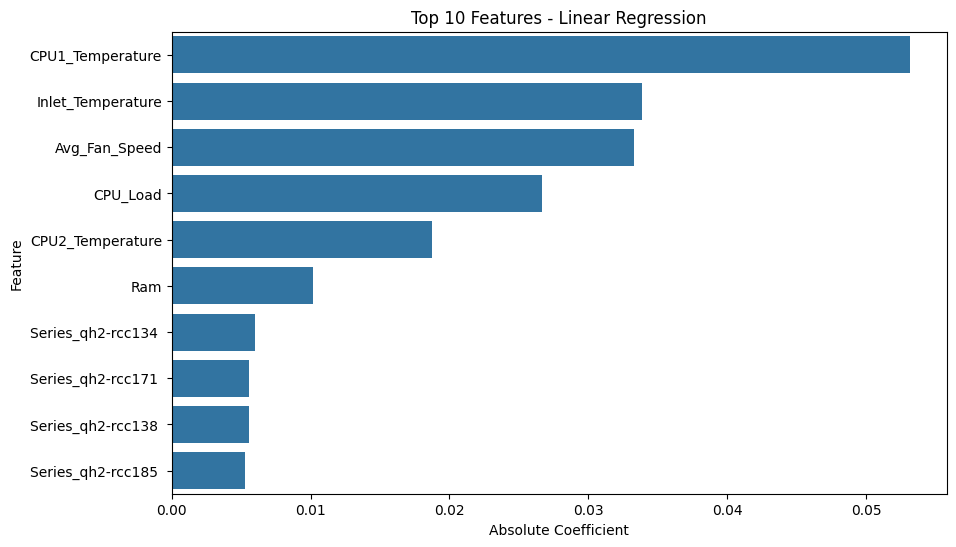

In [42]:
# Linear Regression feature importance

feature_importance = pd.DataFrame({
    'Feature': X_OV.columns,
    'Coefficient': lr.coef_
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Absolute_Coefficient',
    y='Feature'
)

plt.title('Top 10 Features - Linear Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.show()


#### Correlation Analysis

,Feature,Correlation
CPU_Load,CPU_Load,0.913278
CPU1_Temperature,CPU1_Temperature,0.890799
CPU2_Temperature,CPU2_Temperature,0.846144
Ram_Used,Ram_Used,0.669772
Avg_Fan_Speed,Avg_Fan_Speed,0.319204
CPU_cores,CPU_cores,-0.314188
CPU_cores_used,CPU_cores_used,0.251981
Network_RX,Network_RX,0.108537
Network_TX,Network_TX,0.099700
No_Of_Running_vms,No_Of_Running_vms,0.058368


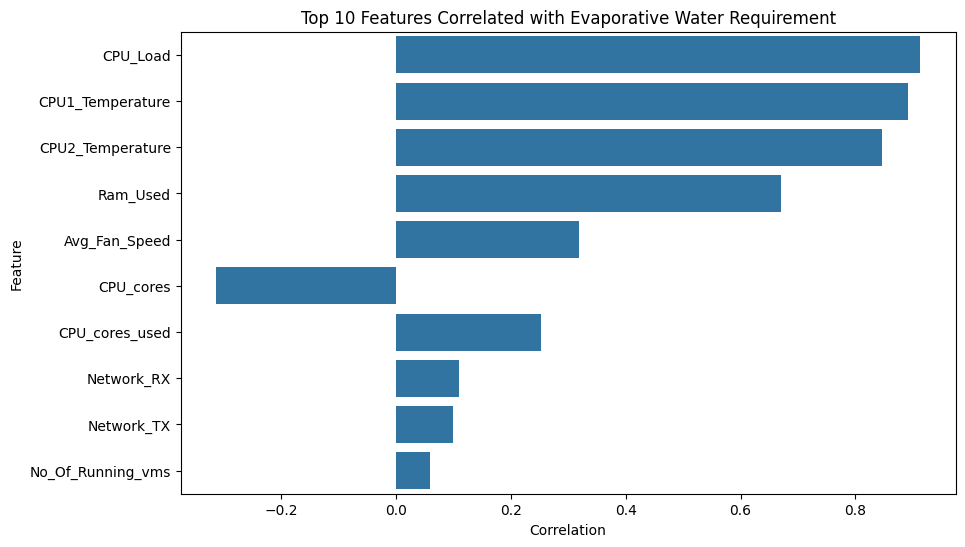

In [43]:
corr_cols = [
    'CPU_Load',
    'Network_RX',
    'Network_TX',
    'Inlet_Temperature',
    'CPU1_Temperature',
    'CPU2_Temperature',
    'Ram',
    'Ram_Used',
    'No_Of_Running_vms',
    'CPU_cores',
    'CPU_cores_used',
    'Avg_Fan_Speed'
]
correlation = data[corr_cols + [
    'Evaporative_Water_Required_LPH'
]].corr()['Evaporative_Water_Required_LPH'].drop(
    'Evaporative_Water_Required_LPH'
)

top_10_corr = correlation.abs().sort_values(
    ascending=False
).head(10)

top_10_corr_df = pd.DataFrame({
    'Feature': top_10_corr.index,
    'Correlation': correlation[top_10_corr.index]
})

display(top_10_corr_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_corr_df,
    x='Correlation',
    y='Feature'
)

plt.title('Top 10 Features Correlated with Evaporative Water Requirement')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

**Observation: CPU load and CPU temperatures exhibit the strongest positive correlations with evaporative water requirement, followed by RAM usage and fan speed. This indicates that higher computational workload and thermal activity are strongly associated with increased cooling water demand. The correlation results are broadly consistent with the Linear Regression feature coefficients.**